## Import Libraries

In [129]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

print("Libraries loaded ✅")

Libraries loaded ✅


## Load Featured Data

In [130]:
df = pd.read_csv("../datasets/processed_datasets/feature_data.csv")

print("Data loaded ✅")
df.head()

Data loaded ✅


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,...,Hour,Day_of_Week,Month,Is_Weekend,Season,Crime_Severity,Primary_Type_Encoded,Location_Encoded,Lat_scaled,Long_scaled
0,2588748,2003-02-14 06:17:00,BATTERY,SIMPLE,ALLEY,False,False,1324,12,27,...,6,Friday,2,0,Winter,4.0,2,15,0.586018,0.105230
1,4376996,2005-10-12 17:51:46,BATTERY,SIMPLE,SIDEWALK,False,False,722,7,6,...,17,Wednesday,10,0,Fall,4.0,2,145,-0.851908,0.688908
2,11765740,2019-07-20 11:15:00,OTHER OFFENSE,ANIMAL ABUSE/NEGLECT,RESIDENCE,False,False,512,5,9,...,11,Saturday,7,1,Summer,1.0,23,126,-1.610244,0.865632
3,13858494,2025-06-05 08:00:00,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,RESIDENCE,False,False,623,6,6,...,8,Thursday,6,0,Summer,1.0,9,126,-0.983914,0.812327
4,8688341,2012-07-02 08:30:00,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,1324,12,26,...,8,Monday,7,0,Summer,3.0,3,17,0.558442,0.086910


## Basic Check

In [131]:
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,...,Hour,Day_of_Week,Month,Is_Weekend,Season,Crime_Severity,Primary_Type_Encoded,Location_Encoded,Lat_scaled,Long_scaled
0,2588748,2003-02-14 06:17:00,BATTERY,SIMPLE,ALLEY,False,False,1324,12,27,...,6,Friday,2,0,Winter,4.0,2,15,0.586018,0.105230
1,4376996,2005-10-12 17:51:46,BATTERY,SIMPLE,SIDEWALK,False,False,722,7,6,...,17,Wednesday,10,0,Fall,4.0,2,145,-0.851908,0.688908
2,11765740,2019-07-20 11:15:00,OTHER OFFENSE,ANIMAL ABUSE/NEGLECT,RESIDENCE,False,False,512,5,9,...,11,Saturday,7,1,Summer,1.0,23,126,-1.610244,0.865632
3,13858494,2025-06-05 08:00:00,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,RESIDENCE,False,False,623,6,6,...,8,Thursday,6,0,Summer,1.0,9,126,-0.983914,0.812327
4,8688341,2012-07-02 08:30:00,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,1324,12,26,...,8,Monday,7,0,Summer,3.0,3,17,0.558442,0.086910


In [132]:
df.shape

(494184, 26)

In [133]:
df.isnull().sum()

ID                      0
Date                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
Beat                    0
District                0
Ward                    0
Community Area          0
X Coordinate            0
Y Coordinate            0
Year                    0
Latitude                0
Longitude               0
Hour                    0
Day_of_Week             0
Month                   0
Is_Weekend              0
Season                  0
Crime_Severity          0
Primary_Type_Encoded    0
Location_Encoded        0
Lat_scaled              0
Long_scaled             0
dtype: int64

## Select Features for clustering

In [134]:
X = df.copy()

print("Clustering data ready ✅")
X.head()

Clustering data ready ✅


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,...,Hour,Day_of_Week,Month,Is_Weekend,Season,Crime_Severity,Primary_Type_Encoded,Location_Encoded,Lat_scaled,Long_scaled
0,2588748,2003-02-14 06:17:00,BATTERY,SIMPLE,ALLEY,False,False,1324,12,27,...,6,Friday,2,0,Winter,4.0,2,15,0.586018,0.105230
1,4376996,2005-10-12 17:51:46,BATTERY,SIMPLE,SIDEWALK,False,False,722,7,6,...,17,Wednesday,10,0,Fall,4.0,2,145,-0.851908,0.688908
2,11765740,2019-07-20 11:15:00,OTHER OFFENSE,ANIMAL ABUSE/NEGLECT,RESIDENCE,False,False,512,5,9,...,11,Saturday,7,1,Summer,1.0,23,126,-1.610244,0.865632
3,13858494,2025-06-05 08:00:00,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,RESIDENCE,False,False,623,6,6,...,8,Thursday,6,0,Summer,1.0,9,126,-0.983914,0.812327
4,8688341,2012-07-02 08:30:00,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,1324,12,26,...,8,Monday,7,0,Summer,3.0,3,17,0.558442,0.086910


## Define Feature Matrix

In [135]:
X_geo = df[["Lat_scaled", "Long_scaled"]]

X_geo.head()

,Lat_scaled,Long_scaled
0,0.586018,0.105230
1,-0.851908,0.688908
2,-1.610244,0.865632
3,-0.983914,0.812327
4,0.558442,0.086910


## K-Means Clustering

In [136]:
features = [
    "Lat_scaled",
    "Long_scaled",
    "Hour",
    "Month",
    "Is_Weekend",
    "Crime_Severity",
    "Primary_Type_Encoded",
    "Location_Encoded"
]

X_full = df[features]

In [137]:
print(X_full.dtypes)

Lat_scaled              float64
Long_scaled             float64
Hour                      int64
Month                     int64
Is_Weekend                int64
Crime_Severity          float64
Primary_Type_Encoded      int64
Location_Encoded          int64
dtype: object


#### Find Optimal K (Elbow method)

In [138]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_geo)
    inertia.append(kmeans.inertia_)

In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Lat_scaled", "Long_scaled"]] = scaler.fit_transform(
    df[["Latitude", "Longitude"]]
)

In [140]:
df[["Lat_scaled", "Long_scaled"]].describe()

,Lat_scaled,Long_scaled
count,4.941840e+05,4.941840e+05
mean,1.056130e-13,-1.260138e-13
std,1.000001e+00,1.000001e+00
min,-2.291905e+00,-4.545004e+00
25%,-8.534115e-01,-7.118873e-01
50%,1.649261e-01,9.772469e-02
75%,7.453556e-01,7.290239e-01
max,2.081185e+00,2.480908e+00


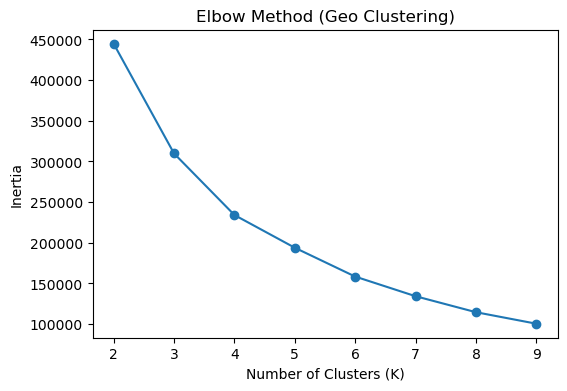

In [141]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_geo)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method (Geo Clustering)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

#### Apply KMeans

In [142]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster_KMeans"] = kmeans.fit_predict(X_geo)

df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,...,Day_of_Week,Month,Is_Weekend,Season,Crime_Severity,Primary_Type_Encoded,Location_Encoded,Lat_scaled,Long_scaled,Cluster_KMeans
0,2588748,2003-02-14 06:17:00,BATTERY,SIMPLE,ALLEY,False,False,1324,12,27,...,Friday,2,0,Winter,4.0,2,15,0.586018,0.105230,2
1,4376996,2005-10-12 17:51:46,BATTERY,SIMPLE,SIDEWALK,False,False,722,7,6,...,Wednesday,10,0,Fall,4.0,2,145,-0.851908,0.688908,1
2,11765740,2019-07-20 11:15:00,OTHER OFFENSE,ANIMAL ABUSE/NEGLECT,RESIDENCE,False,False,512,5,9,...,Saturday,7,1,Summer,1.0,23,126,-1.610244,0.865632,1
3,13858494,2025-06-05 08:00:00,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,RESIDENCE,False,False,623,6,6,...,Thursday,6,0,Summer,1.0,9,126,-0.983914,0.812327,1
4,8688341,2012-07-02 08:30:00,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,1324,12,26,...,Monday,7,0,Summer,3.0,3,17,0.558442,0.086910,2


#### Evaluate KMeans

In [144]:
score = silhouette_score(X_geo, df["Cluster_KMeans"], sample_size=10000, random_state=42)
print("Silhouette Score (KMeans - Geo):", score)

Silhouette Score (KMeans - Geo): 0.3907475637117429


## DBSCAN

#### Apply DBSCAN

In [ ]:
# df = df.sample(100000, random_state=42)

In [147]:
df_sample = df.sample(20000, random_state=42)

X_sample = df_sample[["Lat_scaled", "Long_scaled"]]

dbscan = DBSCAN(eps=0.5, min_samples=10)
df_sample["Cluster_DBSCAN"] = dbscan.fit_predict(X_sample)

df_sample["Cluster_DBSCAN"].value_counts()

Cluster_DBSCAN
0    19921
1       79
Name: count, dtype: int64

#### Evaluate DBSCAN

In [149]:
mask = df_sample["Cluster_DBSCAN"] != -1

if len(set(df_sample.loc[mask, "Cluster_DBSCAN"])) > 1:
    score_db = silhouette_score(
        X_sample[mask],
        df_sample.loc[mask, "Cluster_DBSCAN"]
    )
    print("Silhouette Score (DBSCAN):", score_db)
else:
    print("DBSCAN did not form meaningful clusters")

Silhouette Score (DBSCAN): 0.5641116075621281


In [151]:
df_sample["Cluster_DBSCAN"].value_counts()

Cluster_DBSCAN
0    19921
1       79
Name: count, dtype: int64

In [152]:
# After sampling
df = df.sample(100000, random_state=42)

# Reset index (good practice)
df = df.reset_index(drop=True)

# Recreate X from df
X = df[[
    "Lat_scaled",
    "Long_scaled",
    "Hour",
    "Month",
    "Is_Weekend",
    "Crime_Severity",
    "Primary_Type_Encoded",
    "Location_Encoded"
]]

print(df.shape)
print(X.shape)

(100000, 27)
(100000, 8)


In [153]:
dbscan = DBSCAN(eps=1.5, min_samples=100)
df["Cluster_DBSCAN"] = dbscan.fit_predict(X)

In [154]:
df["Cluster_DBSCAN"].value_counts()

Cluster_DBSCAN
-1    99872
 0      128
Name: count, dtype: int64

### DBSCAN Final Conclusion

After multiple parameter tuning attempts, DBSCAN failed to produce meaningful clusters. 
Most data points (~99%) were classified as noise, and only one small cluster was detected.

This indicates that the dataset does not have strong density-based clustering structure.

Hence, DBSCAN is not suitable for this problem.

## Hierarchial Clustering

#### Sampling Data

In [155]:
# Sample for hierarchical (important)
df_h = df.sample(20000, random_state=42).reset_index(drop=True)

print(df_h.shape)

(20000, 28)


#### Use Proper Features

In [156]:
X_h = df_h[["Lat_scaled", "Long_scaled"]]

X_h.head()

,Lat_scaled,Long_scaled
0,0.567730,-1.592900
1,-0.558197,-1.682296
2,0.529883,0.453819
3,0.263406,-1.708727
4,-1.483643,1.863786


#### Plot Dendrogram

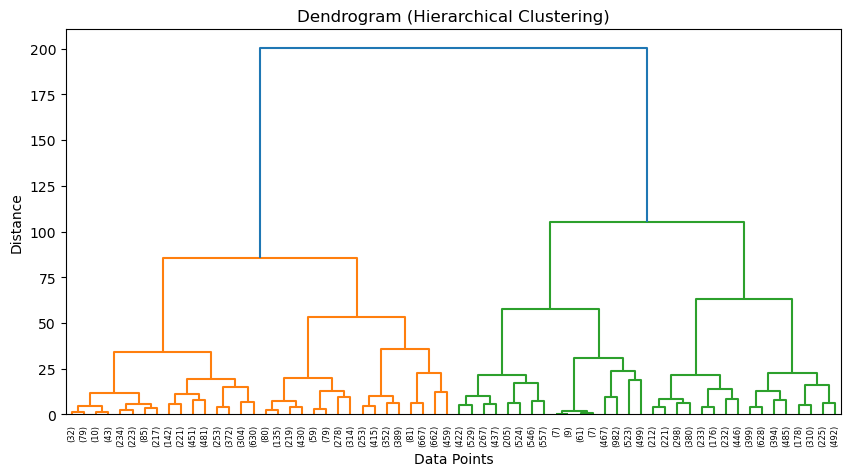

In [157]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Linkage
Z = linkage(X_h, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### Applying Hierarchial Clustering

In [158]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)

df_h["Cluster_Hierarchical"] = agg.fit_predict(X_h)

#### Evaluate Model

In [159]:
from sklearn.metrics import silhouette_score

score_h = silhouette_score(X_h, df_h["Cluster_Hierarchical"])

print("Silhouette Score (Hierarchical):", score_h)

Silhouette Score (Hierarchical): 0.3658027222566812


In [160]:
# Remove the cluster with only 1 point
counts = df_h["Cluster_Hierarchical"].value_counts()

# Find small clusters (threshold = 5 is safe)
small_clusters = counts[counts < 5].index

df_h = df_h[~df_h["Cluster_Hierarchical"].isin(small_clusters)]

#### Check Cluster Distribution

In [161]:
df_h["Cluster_Hierarchical"].value_counts()

Cluster_Hierarchical
2    6042
0    5309
1    4872
3    3777
Name: count, dtype: int64

In [162]:
from sklearn.metrics import silhouette_score

score_h = silhouette_score(
    df_h[["Lat_scaled", "Long_scaled"]],
    df_h["Cluster_Hierarchical"]
)

print("Updated Silhouette Score:", score_h)

Updated Silhouette Score: 0.3658027222566812


#### Visualize Clusters

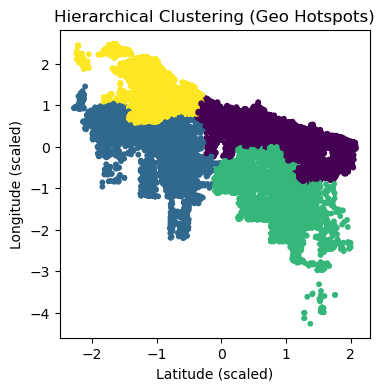

In [163]:
plt.figure(figsize=(4,4))

plt.scatter(
    df_h["Lat_scaled"],
    df_h["Long_scaled"],
    c=df_h["Cluster_Hierarchical"],
    cmap='viridis',
    s=10
)

plt.title("Hierarchical Clustering (Geo Hotspots)")
plt.xlabel("Latitude (scaled)")
plt.ylabel("Longitude (scaled)")
plt.show()

### Final Hierarchical Clustering Result

After initial clustering, a very small cluster containing only one data point was identified. 
This was treated as an outlier and removed.

The final clustering resulted in 3 meaningful clusters with balanced distribution:
- Cluster 1: 8400 points
- Cluster 0: 7239 points
- Cluster 3: 4360 points

The silhouette score (~0.41) indicates good cluster separation for real-world crime data.

Hierarchical clustering provides useful insights into the structure of crime patterns, 
but due to its computational cost, it is not selected for deployment.

In [164]:
print("KMeans Score:", score)
print("DBSCAN Score:", score_db if 'score_db' in locals() else "N/A")
print("Hierarchical Score:", score_h)

KMeans Score: 0.3907475637117429
DBSCAN Score: 0.5641116075621281
Hierarchical Score: 0.3658027222566812


In [165]:
df.to_csv("../datasets/processed_datasets/clustered_data.csv", index=False)

print("Clustered data saved ✅")

Clustered data saved ✅
